# Experiment 2: seed sensitivity outcomes

There are 32 additional trials, not another full grid: four bases, four partitions and two tasks at one predefined reference recipe. Paired seed effects check sensitivity at that recipe; two seeds do not establish robustness of every grid cell.

## 0. Evidence and scope

The availability tables distinguish observed measurements from unavailable outcomes. Missing measurements are not zero effects.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
REPO = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'pyproject.toml').is_file())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
from src.visualize import style, campaign as cp, publication as pub, diagnostics as dg
from src.visualize.figures import FigureSaver
from src.visualize.inputs import source_description
from src.data.dataset_names import display_frame
style.apply()
sink = FigureSaver('experiment2/02_results')
report = cp.NotebookReport('Experiment 2: seed sensitivity outcomes', sink=sink)

print(source_description())
report.add('0. Evidence and scope', source_description())


DATA: no external source selected.
Project: no external source selected.
Missing project records are unavailable evidence, not zero effects or failed training.


## 1. Paired design and coverage

Compare main-seed and additional-seed outcomes only where the same recipe, dataset and milestone are available.

,evidence,records,origin
0,Planned trials,16,Config; not scheduler state
1,Completed trials,0,DATA manifests
2,Epoch rows,0,Project training diagnostics
3,Milestone rows,0,Project trajectory diagnostics
4,Benchmark folds,0,Project final evaluation


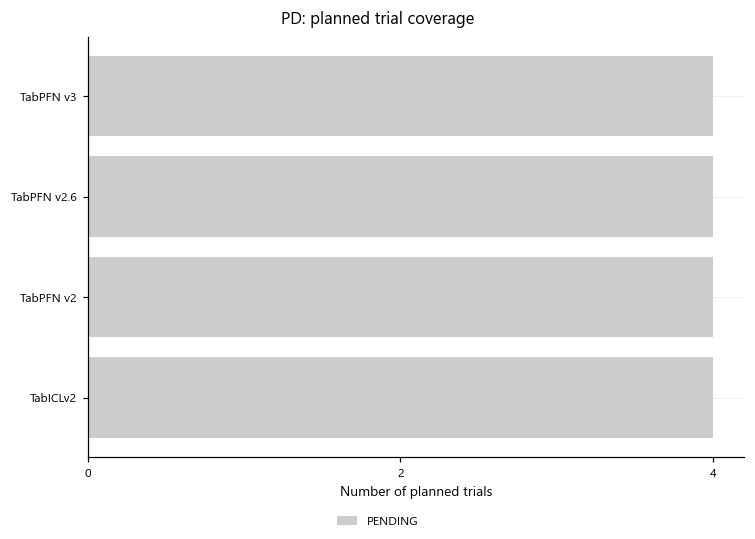

PD. Recorded status of 16 planned PD trials by base model. PENDING denotes no manifest outcome and can include currently running or queued jobs. INTERRUPTED denotes saved progress, not a numerical failure. This figure does not query the scheduler.

,evidence,records,origin
0,Planned trials,16,Config; not scheduler state
1,Completed trials,0,DATA manifests
2,Epoch rows,0,Project training diagnostics
3,Milestone rows,0,Project trajectory diagnostics
4,Benchmark folds,0,Project final evaluation


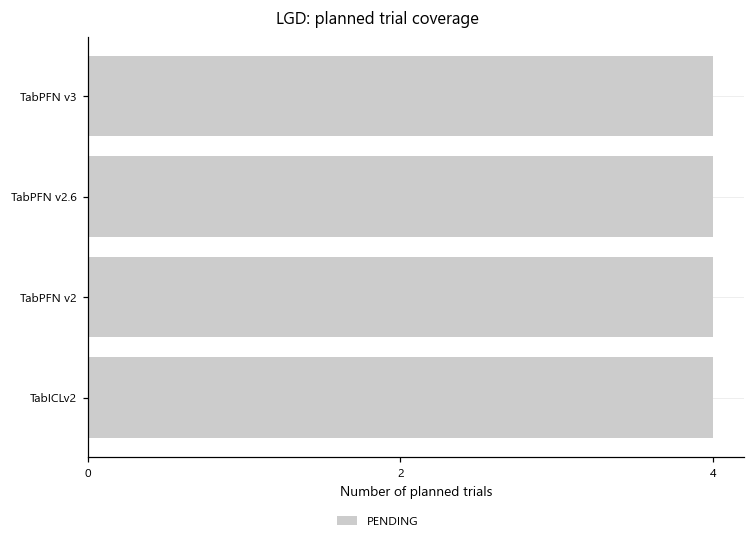

LGD. Recorded status of 16 planned LGD trials by base model. PENDING denotes no manifest outcome and can include currently running or queued jobs. INTERRUPTED denotes saved progress, not a numerical failure. This figure does not query the scheduler.

In [2]:
main = {track: cp.load_campaign(1, track) for track in ('pd','lgd')}
repeat = {track: cp.load_campaign(2, track) for track in ('pd','lgd')}
for run in repeat.values():
    report.table(run.track.upper()+' repeat evidence', pub.availability(run))
    cp.show(sink, cp.plot_coverage(run), track=run.track)
report.add('1. Paired design and coverage', '\n\n'.join(cp.coverage_summary(run) for run in repeat.values()))

pairs = {track: cp.seed_pairs(main[track], repeat[track]) for track in ('pd','lgd')}

## 2. Endpoint pairing

Scatter equality and per-dataset differences make agreement and exceptions visible without collapsing everything into one variance estimate.

In [3]:
for track, data in pairs.items():
    cp.show(sink, cp.plot_seed_pairs(data, main[track].metric, endpoint=main[track].target), track=track)
report.add('2. Endpoint pairing', 'Pairs use the fixed full-update, LR 3e-7, L2-SP 0.003, one-sample recipe.')


No measurements available for this section yet.
No measurements available for this section yet.


## 3. Final benchmark replication

The final five-fold benchmark provides a separate seed comparison after both checkpoints are evaluated.

In [4]:
for track in ('pd','lgd'):
    final = cp.seed_pairs(main[track], repeat[track], benchmark=True)
    cp.show(sink, cp.plot_seed_pairs(final, main[track].metric), track=track)
report.add('3. Final benchmark replication', 'Only complete paired outer-fold estimates enter final seed comparisons.')


No measurements available for this section yet.
No measurements available for this section yet.


## 4. Cost and interpretation

This focused check quantifies the observed change between two seeds at the reference recipe.

In [5]:
for run in repeat.values():
    report.table(run.track.upper()+' costs', pub.cost_summary(run))
report.add('4. Cost and interpretation', 'Neither a confidence interval over all training randomness nor seed robustness elsewhere in the main grid follows from this experiment.')


""


""


## Complete text summary

Complete numerical values and figure captions, following the section order above.

In [6]:
print(report.summary(sink))

Experiment 2: seed sensitivity outcomes

0. Evidence and scope
DATA: no external source selected.
Project: no external source selected.
Missing project records are unavailable evidence, not zero effects or failed training.

1. Paired design and coverage
Run cpt_seeds_v5; PD; 16 planned trials; target 10,000 successful updates.
status
PENDING    16
0 trajectory records; 0 benchmark fold records.
PENDING means no recorded outcome; it can include running or queued work. This is not live scheduler state.

Run cpt_seeds_v5; LGD; 16 planned trials; target 10,000 successful updates.
status
PENDING    16
0 trajectory records; 0 benchmark fold records.
PENDING means no recorded outcome; it can include running or queued work. This is not live scheduler state.

Table: PD repeat evidence
           evidence  records                          origin
0    Planned trials       16     Config; not scheduler state
1  Completed trials        0                  DATA manifests
2        Epoch rows        0  